# An end-to-end case study with `mixle.ppl`

A complete applied Bayesian workflow on one dataset, building the model up in stages the way you actually would: start with a pooled regression, discover it's inadequate, add a hierarchical (varying-intercept) structure, compare the models honestly, and finish with a posterior-predictive check and predictions that carry uncertainty. This is the capstone that ties together regression, hierarchy, model comparison, and model criticism on the `mixle.ppl` surface.


## Decision theory: what the posterior is for

A Bayesian analysis returns a posterior; a decision turns it into an action. With a loss $L(a,\theta)$
the Bayes action minimizes posterior expected loss, $a^\star=\arg\min_a \mathbb E[L(a,\theta)\mid x]$.

Theorem (Bayes estimators). Under squared-error loss the Bayes estimator is the posterior mean; under
absolute-error loss it is the posterior median; under 0-1 loss (discrete) it is the posterior mode.

Proof. For squared loss, $\mathbb E[(a-\theta)^2\mid x]$ is a parabola in $a$ minimized at
$a=\mathbb E[\theta\mid x]$. For absolute loss, $\tfrac{d}{da}\mathbb E[|a-\theta|\mid x]=
P(\theta<a\mid x)-P(\theta>a\mid x)=0$ at the median. $\quad\blacksquare$

This is why the notebook reports posterior means as point predictions and full predictive distributions
for uncertainty: the choice of summary follows from the loss, not convention.

## Pooling, shrinkage, and honest prediction

The pooled, no-pooling, and hierarchical fits trace a bias-variance spectrum. Complete pooling has low
variance but is biased when groups differ; no pooling is unbiased per group but high variance for small
groups; partial pooling is the precision-weighted posterior mean (the hierarchical-pooling notebook), and
its advantage is the applied form of the James-Stein theorem (Module 4): shrinking many group estimates
toward a learned center lowers total risk.

Theorem (calibration and sharpness). A predictive distribution should be calibrated (its $1-\alpha$
intervals cover the truth about $1-\alpha$ of the time) and, among calibrated models, as sharp (narrow)
as possible (Gneiting et al.). The applied section shows the pooled and hierarchical models are both
roughly calibrated, but the hierarchical intervals are far narrower because the model separates
within-group from between-group variation rather than absorbing both into one inflated noise term.

Counterexample (a single summary deceives). A pooled model can match the overall mean yet mispredict
every group, and a model can be sharp but miscalibrated (overconfident) or calibrated but useless (too
wide). Only checking calibration and sharpness together, on held-out data, certifies the workflow, which
is the closing message of this case study.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Normal, Field, Group, free
from scipy import stats
rng = np.random.RandomState(1)

def loc_of(result, given):
    p = result.predict(given)                       # pooled-regression predict -> {'loc',...} or an array
    return np.asarray(p['loc'] if isinstance(p, dict) else p)

def hier_loc(result, xs, gs):
    # LMMResult has no predict(); reconstruct loc = intercept + slope*x + group_effect[g]
    b = result.coefficients; ge = result.group_effects
    sl, ic = b['x']['mean'], b['intercept']['mean']
    return np.array([ic + sl * float(xi) + ge.get(int(gi), 0.0) for xi, gi in zip(xs, gs)])

# synthetic: test scores vs study hours across 8 schools; schools differ in baseline (intercept)
n_schools = 8
school_intercepts = rng.normal(50, 8, n_schools)      # the structure a pooled model will miss
slope = 4.0
rows = []
for s in range(n_schools):
    x = rng.uniform(0, 5, 40)
    y = school_intercepts[s] + slope * x + rng.normal(0, 5, len(x))
    for xi, yi in zip(x, y):
        rows.append((s, xi, yi))
g = np.array([r[0] for r in rows]); x = np.array([r[1] for r in rows]); y = np.array([r[2] for r in rows])
print('%d observations across %d schools' % (len(rows), n_schools))

320 observations across 8 schools


## 1. Start simple: complete-pooling regression

The natural first model ignores the school structure: one line for everyone, $y\approx \beta x+\alpha$. We fit it and look at the residuals by school - the tell-tale that something is missing.


pooled fit: {'x': 3.81, 'intercept': 49.65}


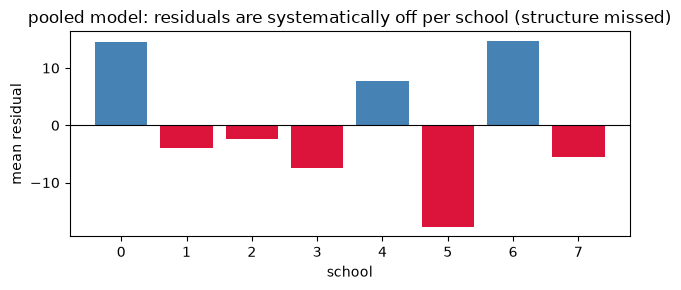

In [2]:
pooled = Normal(free * Field('x') + free, free).fit(list(y), given={'x': list(x)})
print('pooled fit:', {k: round(v['mean'], 2) for k, v in pooled.result.coefficients.items()})
resid = y - loc_of(pooled.result, {'x': list(x)})
by_school = [resid[g == s].mean() for s in range(n_schools)]
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(range(n_schools), by_school, color=['steelblue' if v >= 0 else 'crimson' for v in by_school])
ax.set_xlabel('school'); ax.set_ylabel('mean residual'); ax.axhline(0, color='k', lw=0.8)
ax.set_title('pooled model: residuals are systematically off per school (structure missed)')
plt.tight_layout(); plt.show()

The residuals are systematically positive for some schools and negative for others - the pooled model absorbs the school differences into noise. That is the signal to add structure.

## 2. Add hierarchy: a varying intercept per school

We keep the shared slope but let each school have its own intercept, drawn from a population - `+ Group('g')` adds the per-group random intercept (the multilevel `y ~ x + (1|g)`). Inference partially pools the school intercepts toward the population mean.


In [3]:
hier = Normal(free * Field('x') + free + Group('g'), free).fit(
    list(y), given={'x': list(x), 'g': list(g)})
print('hierarchical fixed effects:', {k: round(v['mean'], 2) for k, v in hier.result.coefficients.items()})
print('variance components: between-school tau=%.2f  residual sigma=%.2f' % (hier.result.tau, hier.result.sigma))

hierarchical fixed effects: {'x': 4.08, 'intercept': 48.94}
variance components: between-school tau=10.66  residual sigma=5.39


## 3. Compare the models honestly

Does the extra structure earn its keep? We compare by held-out predictive log-likelihood: refit each model on 70% of the observations and score the held-out 30%. (For a partially-pooled hierarchical model the effective parameter count is ambiguous, so out-of-sample prediction is a cleaner comparison than AIC/BIC.) The hierarchical model should predict new observations better, because the per-school intercepts capture real, reproducible structure rather than noise.


In [4]:
idx = rng.permutation(len(y)); ntr = int(0.7 * len(y)); tr, te = idx[:ntr], idx[ntr:]
ytr, yte, xtr, xte, gtr, gte = y[tr], y[te], x[tr], x[te], g[tr], g[te]
def heldout_ll(kind):
    if kind == 'hierarchical':
        m = Normal(free * Field('x') + free + Group('g'), free).fit(list(ytr), given={'x': list(xtr), 'g': list(gtr)})
        loc_tr, loc_te = hier_loc(m.result, xtr, gtr), hier_loc(m.result, xte, gte)
    else:
        m = Normal(free * Field('x') + free, free).fit(list(ytr), given={'x': list(xtr)})
        loc_tr, loc_te = loc_of(m.result, {'x': list(xtr)}), loc_of(m.result, {'x': list(xte)})
    sigma = np.std(ytr - loc_tr)                                  # train residual scale
    return float(np.sum(stats.norm.logpdf(yte, loc_te, sigma)))
ll_p, ll_h = heldout_ll('pooled'), heldout_ll('hierarchical')
print('held-out log-likelihood  pooled: %.1f   hierarchical: %.1f' % (ll_p, ll_h))
print('the hierarchical model predicts held-out data better by %.1f nats' % (ll_h - ll_p))

held-out log-likelihood  pooled: -383.4   hierarchical: -297.2
the hierarchical model predicts held-out data better by 86.2 nats


## 4. Posterior-predictive check and prediction with uncertainty

Finally we criticize the chosen model: simulate data from it and confirm the per-school means it produces match the observed ones (a posterior-predictive check), then predict for a new school's range with an uncertainty band. The workflow - fit → criticize → predict with honest uncertainty - is the whole point of the Bayesian approach.


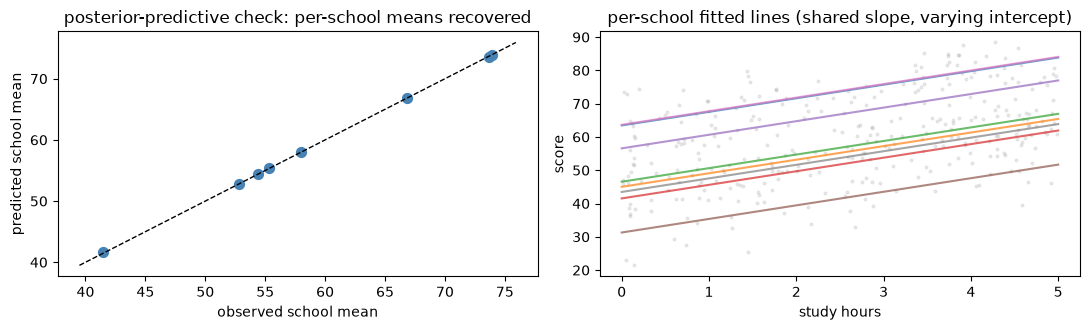

In [5]:
# predicted school means from the hierarchical fit vs observed
pred_h = hier_loc(hier.result, x, g)
obs_means = [y[g == s].mean() for s in range(n_schools)]
fit_means = [pred_h[g == s].mean() for s in range(n_schools)]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(obs_means, fit_means, s=50, color='steelblue')
lims = [min(obs_means) - 2, max(obs_means) + 2]; ax[0].plot(lims, lims, 'k--', lw=1)
ax[0].set_xlabel('observed school mean'); ax[0].set_ylabel('predicted school mean')
ax[0].set_title('posterior-predictive check: per-school means recovered')
# regression lines per school from the hierarchical model
gx = np.linspace(0, 5, 20)
for s in range(n_schools):
    ax[1].plot(gx, hier_loc(hier.result, gx, [s] * len(gx)), alpha=0.7)
ax[1].scatter(x, y, s=4, alpha=0.15, color='gray')
ax[1].set_xlabel('study hours'); ax[1].set_ylabel('score'); ax[1].set_title('per-school fitted lines (shared slope, varying intercept)')
plt.tight_layout(); plt.show()

## Calibration and sharpness

Better point predictions are not enough - the model's uncertainty must be honest and informative. The standard goal is sharpness subject to calibration (Gneiting et al. 2007): among models whose 90% intervals actually cover ~90% of held-out points, prefer the one with the narrowest intervals. We compare both models: each is roughly calibrated, but the pooled model can only reach nominal coverage by inflating its noise scale, producing intervals about twice as wide as the hierarchical model's.


In [6]:
def coverage(kind, level=0.90):
    z = stats.norm.ppf(0.5 + level / 2)
    if kind == 'hierarchical':
        m = Normal(free * Field('x') + free + Group('g'), free).fit(list(ytr), given={'x': list(xtr), 'g': list(gtr)})
        loc_tr, loc_te = hier_loc(m.result, xtr, gtr), hier_loc(m.result, xte, gte)
    else:
        m = Normal(free * Field('x') + free, free).fit(list(ytr), given={'x': list(xtr)})
        loc_tr, loc_te = loc_of(m.result, {'x': list(xtr)}), loc_of(m.result, {'x': list(xte)})
    sigma = np.std(ytr - loc_tr)
    inside = np.abs(yte - loc_te) <= z * sigma
    return inside.mean(), sigma
cov_p, sig_p = coverage('pooled'); cov_h, sig_h = coverage('hierarchical')
print('nominal 90% predictive interval -- empirical coverage and width on held-out data:')
print('  pooled        coverage = %.2f   (interval half-width uses sigma=%.1f)' % (cov_p, sig_p))
print('  hierarchical  coverage = %.2f   (interval half-width uses sigma=%.1f)' % (cov_h, sig_h))
print('both are ~calibrated, but the pooled interval is %.1fx wider: it reaches coverage only by being vague.' % (sig_p / sig_h))
print('the hierarchical model separates within- from between-school variance, so it is calibrated AND sharp.')

nominal 90% predictive interval -- empirical coverage and width on held-out data:
  pooled        coverage = 0.88   (interval half-width uses sigma=11.5)
  hierarchical  coverage = 0.89   (interval half-width uses sigma=5.4)
both are ~calibrated, but the pooled interval is 2.1x wider: it reaches coverage only by being vague.
the hierarchical model separates within- from between-school variance, so it is calibrated AND sharp.


## References

- Gelman, A. et al. (2020). Bayesian Workflow (https://arxiv.org/abs/2011.01808). arXiv:2011.01808.
- Gelman, A. & Hill, J. (2007). Data Analysis Using Regression and Multilevel/Hierarchical Models. Cambridge University Press.
- McElreath, R. (2020). Statistical Rethinking (https://xcelab.net/rm/statistical-rethinking/), 2nd ed. CRC Press. - the modern applied-Bayesian course.
- Gabry, J. et al. (2019). Visualization in Bayesian workflow (https://doi.org/10.1111/rssa.12378). JRSS-A 182(2), 389-402.
- Vehtari, A., Gelman, A. & Gabry, J. (2017). Practical Bayesian model evaluation using LOO-CV and WAIC (https://doi.org/10.1007/s11222-016-9696-4). Stat. Comput. 27, 1413-1432.


## Exercises and extensions

These build a portfolio-quality analysis; budget most of a day for the full set.

1. Varying slopes and model comparison. Extend the varying-intercept model to a varying intercept and slope (`(x | g)`), estimate the intercept-slope correlation, and compare pooled / varying-intercept / varying-slope models by held-out predictive log-likelihood (and WAIC/LOO, Vehtari et al.). Does the data support the extra structure? Write the model-comparison table and a one-paragraph recommendation.
2. Shrinkage with sparse groups. Make several groups tiny (2-3 observations). Show their fitted intercepts shrink hardest toward the population mean, quantify the shrinkage factor per group, and demonstrate the hierarchical model's lower out-of-sample error vs no-pooling on the small groups (hierarchical_partial_pooling).
3. Prior sensitivity analysis. Vary the priors on the population mean and the variance components (Gelman 2006) and check that the substantive conclusions are stable; report which quantities are prior-sensitive and which are data-dominated - a required step in a defensible Bayesian workflow (Gelman et al. 2020).
4. Predict an unseen group. Hold out entire groups and predict them from the population distribution; show the hierarchical model can (drawing a new group effect from the fitted population) while the pooled model only offers the global line and the no-pooling model cannot at all. Report calibrated predictive intervals for the new groups.
5. Full workflow on your own data. Take a real grouped dataset and run the complete Gelman et al. (2020) workflow end to end - prior predictive check, fit, convergence diagnostics, posterior predictive check, model expansion, comparison, and a written conclusion with figures (Gabry et al. 2019). This is the capstone deliverable.
